<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/notebooks/underfitting_and_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Underfitting and Overfitting – Interactive Demo

In this demo, we use polynomial regression to explore the concepts of **underfitting** and **overfitting**.

- The true function we want to learn is a simple **quadratic** curve.
- We generate noisy observations of that curve.
- You can interactively adjust:
  - The **degree** of the polynomial model (its capacity)
  - The **noise level** added to the data

Use the sliders to observe how model complexity and noise affect both **training** and **test error**.

In [ ]:
# Install ipywidgets if not already available
!pip install ipywidgets --quiet

from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Base data (same for all runs)
np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
# y_true = np.sin(2 * np.pi * X).ravel()
y_true = 4 * (X.ravel() - 0.5) ** 2

# Interactive plot function
def plot_polynomial_fit(degree=1, noise_std=0.1):
    # Generate noisy labels
    y = y_true + noise_std * np.random.randn(n_samples)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Polynomial features
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions and errors
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Plotting
    X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
    y_plot = model.predict(poly.transform(X_plot))

    plt.figure(figsize=(7, 5))
    plt.scatter(X_train, y_train, color='blue', label='Train data', s=20)
    plt.plot(X_plot, y_plot, color='red', label=f'Degree {degree}')
    plt.plot(X, y_true, '--', color='green', label='True function')
    plt.title(f"Train MSE = {train_mse:.4f} | Test MSE = {test_mse:.4f} | Noise std = {noise_std}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Activate interactive widgets
interact(plot_polynomial_fit, degree=(1, 15), noise_std=(0.0, 1.0, 0.05))

interactive(children=(IntSlider(value=1, description='degree', max=15, min=1), FloatSlider(value=0.1, descript…

<function __main__.plot_polynomial_fit(degree=1, noise_std=0.1)>

# 📊 MSE vs Polynomial Degree

This plot shows how the **training** and **test Mean Squared Error (MSE)** change as we increase the degree of the polynomial model.

- We compare two scenarios:
  - Low noise (`noise_std = 0.15`)
  - High noise (`noise_std = 0.45`)
  
Key insights:
- Low-degree models may underfit (high error on both sets)
- High-degree models may overfit (low training error but high test error)
- Higher noise levels make overfitting occur earlier

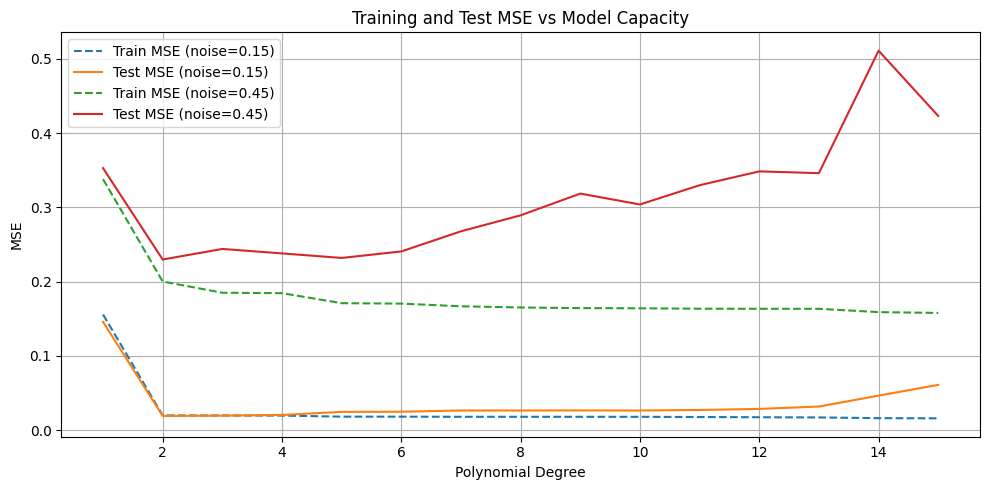

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Base data
np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
#y_true = np.sin(2 * np.pi * X).ravel()
y_true = 4 * (X.ravel() - 0.5) ** 2
degrees = range(1, 16)
noise_levels = [0.15, 0.45]

plt.figure(figsize=(10, 5))

for noise_std in noise_levels:
    y = y_true + noise_std * np.random.randn(n_samples)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    train_mse = []
    test_mse = []

    for degree in degrees:
        poly = PolynomialFeatures(degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        train_mse.append(mean_squared_error(y_train, y_train_pred))
        test_mse.append(mean_squared_error(y_test, y_test_pred))

    # Plot for current noise level
    plt.plot(degrees, train_mse, linestyle='--', label=f'Train MSE (noise={noise_std})')
    plt.plot(degrees, test_mse, label=f'Test MSE (noise={noise_std})')

plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.title('Training and Test MSE vs Model Capacity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()